# Physics-Informed Machine Learning

Neural networks trained purely on data extrapolate poorly when data is sparse and noisy. In many science problems we *also* know an equation the data must (approximately) satisfy. PIML uses that equation as a soft constraint in the loss.

Two flavors:
- **Forward problem** — given the equation and a few measurements, recover the full solution (including outside the observed window).
- **Inverse problem** — given measurements, recover *both* the solution and the unknown coefficients of the equation.

We will demonstrate both on a damped pendulum.

## Preamble

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm.notebook import trange

import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

# Pick the fastest backend available. Swap to 'cuda' or 'cpu' if needed.
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi'] = 110

Using device: mps


## The system: damped nonlinear pendulum

$$\ddot{\theta}(t) + \frac{g}{L}\sin\bigl(\theta(t)\bigr) + b\,\dot{\theta}(t) = 0$$

Two physical parameters: $g/L$ (gravity over length) and $b$ (friction coefficient). Initial conditions: $\theta(0)=1$ rad, $\dot{\theta}(0)=0$.

We pick this because it is intuitive (a swing slowing down) and nonlinear (the $\sin\theta$ term). The same recipe applies unchanged to PDEs with spatial derivatives.

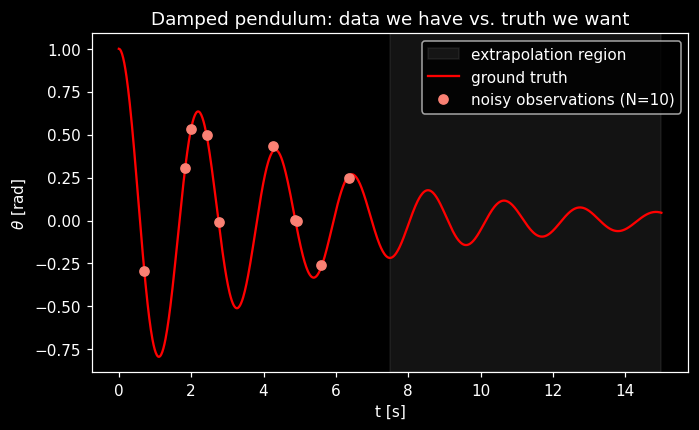

In [55]:
# True parameters (used to generate "ground truth"; in a real experiment we would not know these)
g_over_L_true = 9.0
b_true = 0.4

# Time domain
T_total = 15.0          # full simulation window (seconds)
T_obs   = 7.5           # we only observe data in [0, T_obs]; [T_obs, T_total] is extrapolation

# ODE for solve_ivp: state = [theta, theta_dot]
def pendulum_rhs(t, y, g_over_L, b):
    theta, theta_dot = y
    return [theta_dot, -g_over_L * np.sin(theta) - b * theta_dot]

t_dense = np.linspace(0, T_total, 1000)
sol = solve_ivp(pendulum_rhs, (0, T_total), [1.0, 0.0],
                t_eval=t_dense, args=(g_over_L_true, b_true), rtol=1e-8)
theta_true = sol.y[0]

# Sparse, noisy observations only in [0, T_obs]
N_obs = 10
noise_std = 0.02
t_obs = np.sort(np.random.uniform(0, T_obs, size=N_obs))
theta_obs_clean = np.interp(t_obs, t_dense, theta_true)
theta_obs = theta_obs_clean + np.random.normal(0, noise_std, size=N_obs)

# Plot
fig, ax = plt.subplots()
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='ground truth')
ax.plot(t_obs, theta_obs, 'o', color='C3', label=f'noisy observations (N={N_obs})')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Damped pendulum: data we have vs. truth we want')
ax.legend(); plt.show()

## The model

A small MLP from $t \to \theta(t)$. We use **tanh** activations because we will need smooth second derivatives ($\ddot\theta$ via autograd), and tanh has them. We also internally rescale $t$ to $[-1,1]$ inside `forward`, so the network sees inputs in a healthy range.

The baseline and the PINN below share the same architecture — they only differ in the loss.

In [56]:
class MLP(nn.Module):
    def __init__(self, t_max=T_total, hidden=64, n_layers=3):
        super().__init__()
        self.t_max = t_max
        layers = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        # internal rescaling: t in [0, T_total] -> [-1, 1]
        t_scaled = 2.0 * t / self.t_max - 1.0
        return self.net(t_scaled)


# Tensors on device
t_obs_t     = torch.tensor(t_obs, dtype=torch.float32, device=device).unsqueeze(1)
theta_obs_t = torch.tensor(theta_obs, dtype=torch.float32, device=device).unsqueeze(1)
t_full_t    = torch.tensor(t_dense, dtype=torch.float32, device=device).unsqueeze(1)

## Baseline: data-only

Fit $t \mapsto \theta(t)$ with MSE on the observations. No physics.

baseline:   0%|          | 0/5000 [00:00<?, ?it/s]

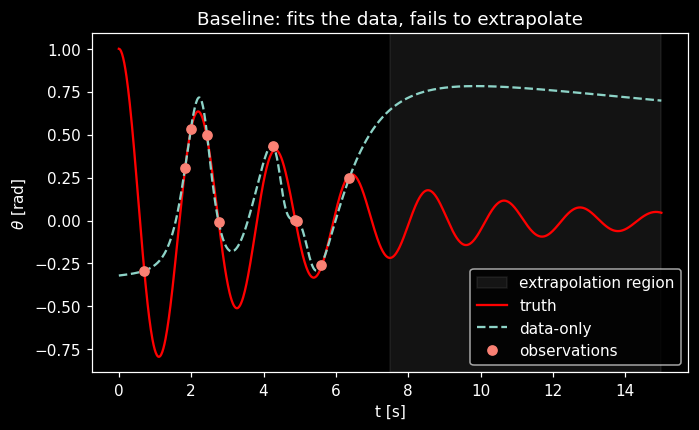

In [57]:
model_baseline = MLP().to(device)
opt = torch.optim.Adam(model_baseline.parameters(), lr=1e-3)

losses_baseline = []
for step in trange(5000, desc='baseline'):
    opt.zero_grad()
    loss = ((model_baseline(t_obs_t) - theta_obs_t) ** 2).mean()
    loss.backward()
    opt.step()
    losses_baseline.append(loss.item())

with torch.no_grad():
    theta_pred_baseline = model_baseline(t_full_t).cpu().numpy().squeeze()

fig, ax = plt.subplots()
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_baseline, 'C0--', lw=1.5, label='data-only')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Baseline: fits the data, fails to extrapolate')
ax.legend(); plt.show()

## Adding physics: the residual loss

The pendulum equation says that for the *true* solution $\theta(t)$, the residual

$$r(t) \;=\; \ddot\theta(t) + \frac{g}{L}\sin\bigl(\theta(t)\bigr) + b\,\dot\theta(t)$$

is identically zero. We turn this into a loss term.

Given the network output $\theta_\mathrm{NN}(t)$, we get $\dot\theta_\mathrm{NN}$ and $\ddot\theta_\mathrm{NN}$ via `torch.autograd.grad` (the same primitive you used in Tutorial 1, just applied to the network output instead of a loss). The total loss is

$$\mathcal{L} \;=\; \mathcal{L}_\mathrm{data} \;+\; \lambda\,\mathcal{L}_\mathrm{physics}$$

with $\mathcal{L}_\mathrm{physics} = \mathrm{mean}\,r(t_i)^2$ on **collocation points** $t_i$ sampled across the *full* domain — including the extrapolation region. The physics term has no labels; it just penalizes any solution that violates the ODE.

In [59]:
def derivatives(model, t):
    """Return theta, theta_dot, theta_ddot at points t. t must require grad."""
    theta = model(t)
    theta_dot = torch.autograd.grad(theta, t,
                                    grad_outputs=torch.ones_like(theta),
                                    create_graph=True)[0]
    theta_ddot = torch.autograd.grad(theta_dot, t,
                                     grad_outputs=torch.ones_like(theta_dot),
                                     create_graph=True)[0]
    return theta, theta_dot, theta_ddot


def physics_residual(model, t, g_over_L, b):
    theta, theta_dot, theta_ddot = derivatives(model, t)
    return theta_ddot + g_over_L * torch.sin(theta) + b * theta_dot

## PINN training (forward problem)

True $g/L$ and $b$ are *given* — we are solving for $\theta(t)$, including in the extrapolation region.

In [74]:
model_pinn = MLP().to(device)
opt = torch.optim.Adam(model_pinn.parameters(), lr=1e-3)

N_coll = 200
lambda_phys = 0.1
n_steps = 5000

losses_data, losses_phys = [], []
for step in trange(n_steps, desc='PINN'):
    opt.zero_grad()

    # data loss
    L_data = ((model_pinn(t_obs_t) - theta_obs_t) ** 2).mean()

    # physics loss on freshly resampled collocation points (cheap regularization)
    t_coll = torch.rand(N_coll, 1, device=device) * T_total
    t_coll.requires_grad_(True)
    r = physics_residual(model_pinn, t_coll, g_over_L_true, b_true)
    L_phys = (r ** 2).mean()

    loss = L_data + lambda_phys * L_phys
    loss.backward()
    opt.step()

    losses_data.append(L_data.item())
    losses_phys.append(L_phys.item())

PINN:   0%|          | 0/5000 [00:00<?, ?it/s]

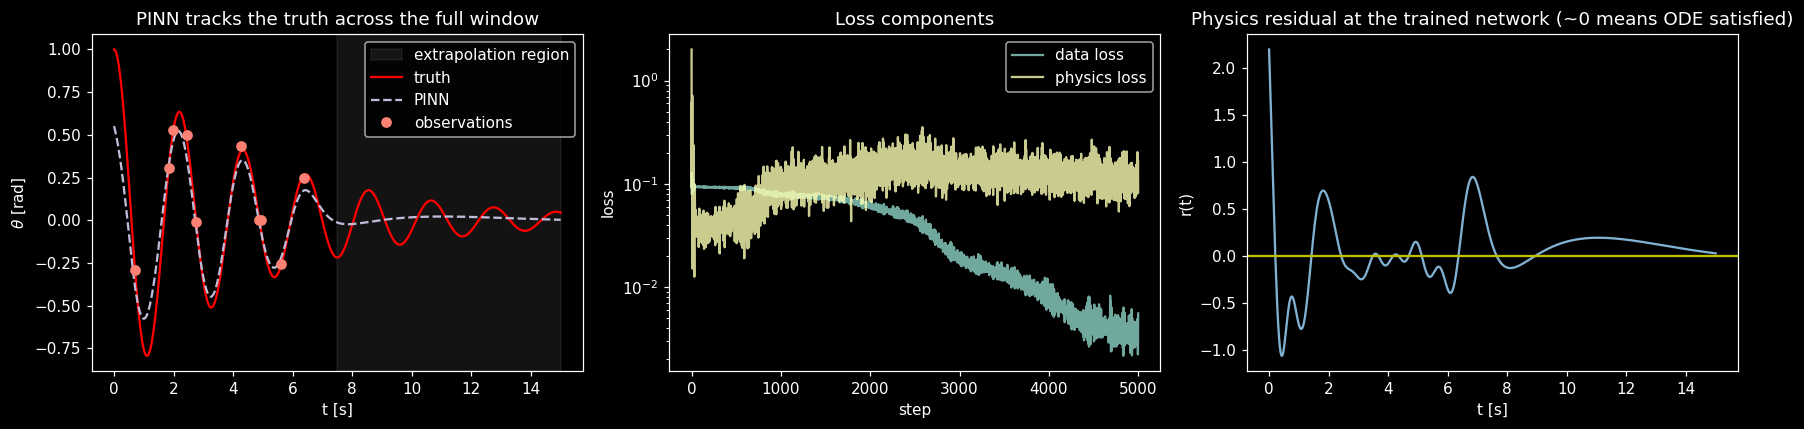

In [75]:
# Predictions over the full window
with torch.no_grad():
    theta_pred_pinn = model_pinn(t_full_t).cpu().numpy().squeeze()

# Residual on a fine grid (needs grad to compute derivatives)
t_grid = torch.linspace(0, T_total, 500, device=device).unsqueeze(1).requires_grad_(True)
r_grid = physics_residual(model_pinn, t_grid, g_over_L_true, b_true).detach().cpu().numpy().squeeze()
t_grid_np = t_grid.detach().cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_pinn, 'C2--', lw=1.5, label='PINN')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('PINN tracks the truth across the full window')
ax.legend()

ax = axes[1]
ax.semilogy(losses_data, label='data loss', alpha=0.8)
ax.semilogy(losses_phys, label='physics loss', alpha=0.8)
ax.set_xlabel('step'); ax.set_ylabel('loss'); ax.set_title('Loss components')
ax.legend()

ax = axes[2]
ax.plot(t_grid_np, r_grid, 'C4-')
ax.axhline(0, color='y', lw=1.5)
ax.set_xlabel('t [s]'); ax.set_ylabel('r(t)')
ax.set_title('Physics residual at the trained network (~0 means ODE satisfied)')

plt.tight_layout(); plt.show()

## Inverse problem: discover $g/L$ and $b$ from data

Now imagine you only have the noisy observations and you do *not* know $g/L$ or $b$. The exact same loss works — just promote the parameters to learnable tensors and add them to the optimizer.

Practical detail: we learn $\log(g/L)$ and $\log(b)$ instead of the values directly, so they stay positive and the gradient magnitudes are well-behaved. We also give them a slightly larger learning rate than the network weights.

In [76]:
# Re-seed so this cell is reproducible on its own
torch.manual_seed(0)

model_inv = MLP().to(device)

# Initialize parameters far from truth (truth is 9.0 and 0.4)
log_g_over_L = nn.Parameter(torch.log(torch.tensor(3.0, device=device)))
log_b        = nn.Parameter(torch.log(torch.tensor(0.05, device=device)))

# Separate learning rates: physical params benefit from a faster lr than network weights
opt = torch.optim.Adam([
    {'params': model_inv.parameters(), 'lr': 1e-3},
    {'params': [log_g_over_L, log_b],  'lr': 5e-3},
])

n_steps = 5000
g_history, b_history = [], []
for step in trange(n_steps, desc='inverse'):
    opt.zero_grad()

    g_over_L = torch.exp(log_g_over_L)
    b        = torch.exp(log_b)

    L_data = ((model_inv(t_obs_t) - theta_obs_t) ** 2).mean()

    t_coll = torch.rand(N_coll, 1, device=device) * T_total
    t_coll.requires_grad_(True)
    r = physics_residual(model_inv, t_coll, g_over_L, b)
    L_phys = (r ** 2).mean()

    loss = L_data + lambda_phys * L_phys
    loss.backward()
    opt.step()

    g_history.append(g_over_L.item())
    b_history.append(b.item())

print(f'Recovered g/L = {g_history[-1]:.3f}   (truth: {g_over_L_true})')
print(f'Recovered b   = {b_history[-1]:.3f}   (truth: {b_true})')

inverse:   0%|          | 0/5000 [00:00<?, ?it/s]

Recovered g/L = 1.773   (truth: 9.0)
Recovered b   = 0.388   (truth: 0.4)


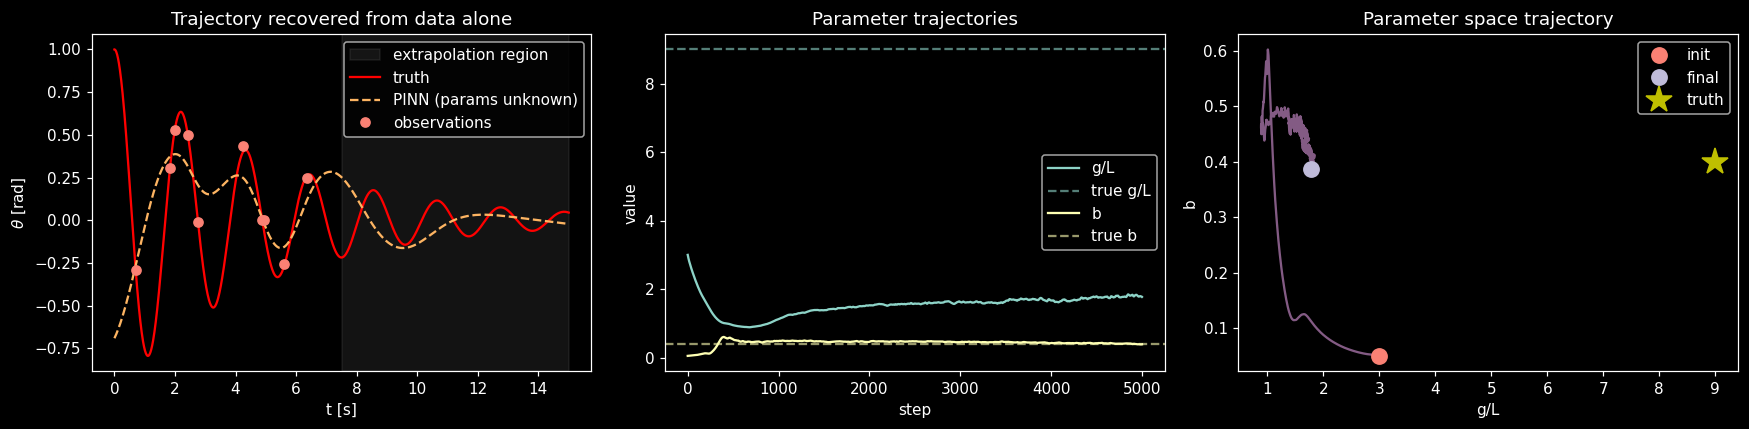

In [77]:
with torch.no_grad():
    theta_pred_inv = model_inv(t_full_t).cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_inv, 'C5--', lw=1.5, label='PINN (params unknown)')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Trajectory recovered from data alone')
ax.legend()

ax = axes[1]
ax.plot(g_history, label='g/L', color='C0')
ax.axhline(g_over_L_true, color='C0', linestyle='--', alpha=0.6, label='true g/L')
ax.plot(b_history, label='b', color='C1')
ax.axhline(b_true, color='C1', linestyle='--', alpha=0.6, label='true b')
ax.set_xlabel('step'); ax.set_ylabel('value')
ax.set_title('Parameter trajectories')
ax.legend()

ax = axes[2]
ax.plot(g_history, b_history, '-', color='C7', alpha=0.7)
ax.plot(g_history[0], b_history[0], 'o', color='C3', markersize=10, label='init')
ax.plot(g_history[-1], b_history[-1], 'o', color='C2', markersize=10, label='final')
ax.plot(g_over_L_true, b_true, '*', color='y', markersize=18, label='truth')
ax.set_xlabel('g/L'); ax.set_ylabel('b')
ax.set_title('Parameter space trajectory')
ax.legend()

plt.tight_layout(); plt.show()

## What went wrong?

The forward problem worked: the network had to fit a known oscillatory signal and the physics constraints kept it on track. The inverse problem couples the network's output and the unknown parameters, so any error in the network's representation of $\theta(t)$ — especially in $\ddot\theta$, which sits inside the residual — feeds back into wrong parameter estimates.

Vanilla MLPs "prefer" smooth, low-frequency functions and struggle to fit oscillations cleanly. Our pendulum has ~7 oscillations across the window — well into the regime where a plain tanh MLP does poorly.

A standard fix is to feed the network a **Fourier feature embedding** instead of raw $t$:

$$t \;\mapsto\; \bigl[\sin(\pi t/T),\,\cos(\pi t/T),\,\sin(2\pi t/T),\,\cos(2\pi t/T),\,\dots\bigr]$$

Same MLP behind it, just a more expressive input representation. Oscillatory functions become easy to represent.

In [78]:
class FourierMLP(nn.Module):
    def __init__(self, t_max=T_total, n_freqs=10, hidden=64, n_layers=3):
        super().__init__()
        self.t_max = t_max
        # fixed (non-learned) frequencies: pi, 2*pi, ..., n_freqs*pi
        freqs = torch.arange(1, n_freqs + 1, dtype=torch.float32) * np.pi
        self.register_buffer('freqs', freqs)

        layers = [nn.Linear(2 * n_freqs, hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers += [nn.Linear(hidden, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        ang = (t / self.t_max) * self.freqs       # (B, n_freqs)
        feats = torch.cat([torch.sin(ang), torch.cos(ang)], dim=-1)
        return self.net(feats)

## Inverse problem, take two — with Fourier features

Same loss, same optimizer setup, same initialization for the unknown parameters. Only the architecture has changed.

In [79]:
torch.manual_seed(0)

model_inv_f = FourierMLP().to(device)

log_g_over_L = nn.Parameter(torch.log(torch.tensor(3.0, device=device)))
log_b        = nn.Parameter(torch.log(torch.tensor(0.05, device=device)))

opt = torch.optim.Adam([
    {'params': model_inv_f.parameters(), 'lr': 1e-3},
    {'params': [log_g_over_L, log_b],    'lr': 5e-3},
])

n_steps = 5000
g_history_f, b_history_f = [], []
for step in trange(n_steps, desc='inverse (Fourier)'):
    opt.zero_grad()

    g_over_L = torch.exp(log_g_over_L)
    b        = torch.exp(log_b)

    L_data = ((model_inv_f(t_obs_t) - theta_obs_t) ** 2).mean()

    t_coll = torch.rand(N_coll, 1, device=device) * T_total
    t_coll.requires_grad_(True)
    r = physics_residual(model_inv_f, t_coll, g_over_L, b)
    L_phys = (r ** 2).mean()

    loss = L_data + lambda_phys * L_phys
    loss.backward()
    opt.step()

    g_history_f.append(g_over_L.item())
    b_history_f.append(b.item())

print(f'Recovered g/L = {g_history_f[-1]:.3f}   (truth: {g_over_L_true})')
print(f'Recovered b   = {b_history_f[-1]:.3f}   (truth: {b_true})')

inverse (Fourier):   0%|          | 0/5000 [00:00<?, ?it/s]

Recovered g/L = 8.984   (truth: 9.0)
Recovered b   = 0.412   (truth: 0.4)


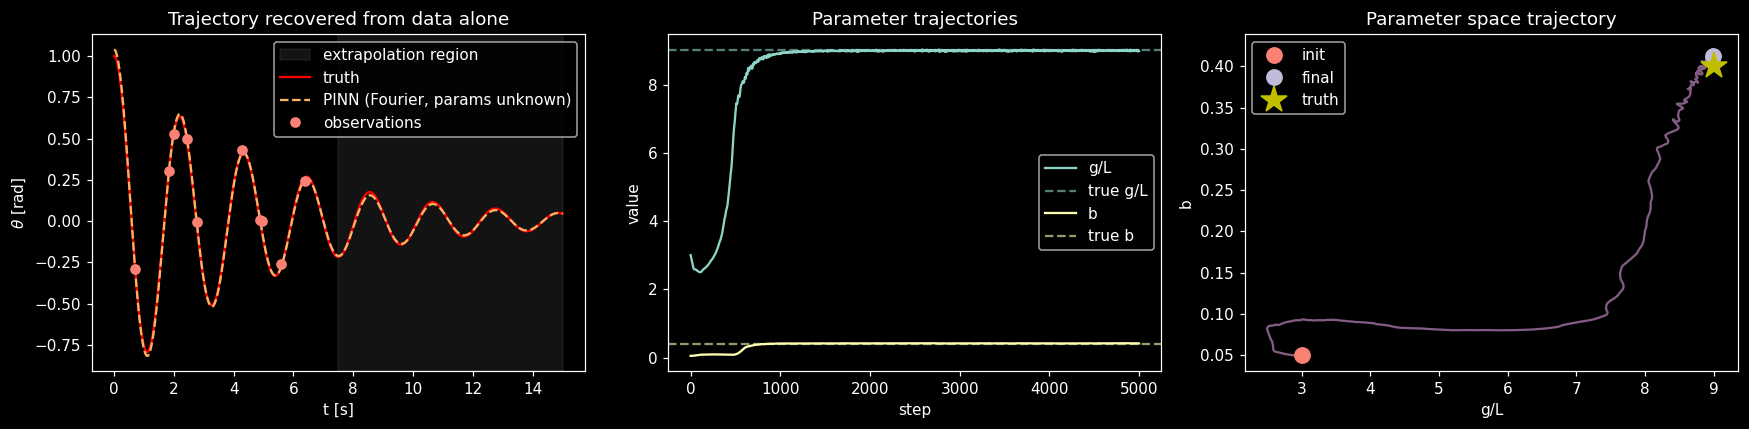

In [80]:
with torch.no_grad():
    theta_pred_inv_f = model_inv_f(t_full_t).cpu().numpy().squeeze()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.axvspan(T_obs, T_total, color='gray', alpha=0.15, label='extrapolation region')
ax.plot(t_dense, theta_true, 'r-', lw=1.5, label='truth')
ax.plot(t_dense, theta_pred_inv_f, 'C5--', lw=1.5, label='PINN (Fourier, params unknown)')
ax.plot(t_obs, theta_obs, 'o', color='C3', label='observations')
ax.set_xlabel('t [s]'); ax.set_ylabel(r'$\theta$ [rad]')
ax.set_title('Trajectory recovered from data alone')
ax.legend()

ax = axes[1]
ax.plot(g_history_f, label='g/L', color='C0')
ax.axhline(g_over_L_true, color='C0', linestyle='--', alpha=0.6, label='true g/L')
ax.plot(b_history_f, label='b', color='C1')
ax.axhline(b_true, color='C1', linestyle='--', alpha=0.6, label='true b')
ax.set_xlabel('step'); ax.set_ylabel('value')
ax.set_title('Parameter trajectories')
ax.legend()

ax = axes[2]
ax.plot(g_history_f, b_history_f, '-', color='C7', alpha=0.7)
ax.plot(g_history_f[0], b_history_f[0], 'o', color='C3', markersize=10, label='init')
ax.plot(g_history_f[-1], b_history_f[-1], 'o', color='C2', markersize=10, label='final')
ax.plot(g_over_L_true, b_true, '*', color='y', markersize=18, label='truth')
ax.set_xlabel('g/L'); ax.set_ylabel('b')
ax.set_title('Parameter space trajectory')
ax.legend()

plt.tight_layout(); plt.show()

## Where to go next

PIML is a large family. The recipe you just used — encode known physics as a soft constraint, optionally promote unknown coefficients to learnable parameters — generalizes:

- **PINNs for PDEs** — same idea with spatial derivatives. Burgers, Navier-Stokes, heat, wave, Schrödinger have all been tackled this way.
- **Operator learning** (FNO, DeepONet) — instead of solving one instance, learn the *map* from PDE inputs (forcing, boundary conditions) to solutions. Generalizes across problem instances.
- **Equivariant networks** (E(3)-NN, SE(3)-Transformer) — bake symmetries (rotation, translation, permutation) into the architecture. Heavily used for molecules, fluids, particle physics.
- **Hybrid physics-ML** — keep the trusted numerical solver, learn only the unknown sub-grid term (closure modeling). Common in climate, materials, biology.
- **Architecture choices that beat spectral bias** — Fourier features (used here), SIREN (sine activations), and adaptive collocation strategies all help when the target is oscillatory or sharp.

**Pick a known equation in your field. Use it as a soft constraint. See what you can recover from the data you already have.**